# Aggregate LogBB data

The purpose of this notebook is to retrieve all compounds from various datasets to predict Log BB for a multicompartment functional model. 

In [ ]:
from pathlib import Path
import pathlib
import csv

from collections import Counter
import numpy as np
import pandas as pd
import seaborn as sns
from tqdm.notebook import tqdm

from rdkit import Chem
from rdkit.Chem import AllChem, DataStructs
from rdkit.Chem.Scaffolds import MurckoScaffold
from rdkit import Chem
from rdkit.Chem import Draw

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image, ImageDraw, ImageFont

Protein and data variables.

In [2]:
readout = 'log_bb'

In [3]:
# define paths
HERE = Path(pathlib.Path.cwd())
DATA = HERE / f"data_{readout}"
DATA.mkdir(parents=True, exist_ok=True)

Read in local csv files.

In [110]:
import pandas as pd
import os
from glob import glob

data_dir = "_datasets"
csv_files = glob(os.path.join(data_dir, "*.csv"))

merged_df = pd.DataFrame()

for f in csv_files:
    print(f"Reading: {f}")
    try:
        df = pd.read_csv(
            f,
            sep=None,             
            engine="python",   
            encoding="utf-8",   
            on_bad_lines="skip"    
        )
    except Exception as e:
        print(f"Skipping {f} - read error: {e}")
        continue

    df.columns = [c.strip().lower() for c in df.columns]

    smiles_col = next((c for c in df.columns if "smiles" in c), None)
    logbb_col  = next((c for c in df.columns if "log_bb" in c or "log_bb" in c), None)

    if not smiles_col or not logbb_col:
        print(f"Skipping {f} - missing SMILES or logBB column")
        continue

    # Add tag for unique ID
    tag = os.path.basename(f)[:3].upper()

    df["compound_id"] = [f"{i}_{tag}" for i in range(1, len(df) + 1)]

    # Keep only relevant columns
    df = df[["compound_id", smiles_col, logbb_col]]
    df.columns = ["compound_id", "smiles", "log_bb"]

    merged_df = pd.concat([merged_df, df], ignore_index=True)

print(f"\nMerged {len(csv_files)} files successfully. Final rows: {len(merged_df)}")


Reading: _datasets/zhu.csv
Reading: _datasets/shaker.csv
Reading: _datasets/b3db.csv

Merged 3 files successfully. Final rows: 9246


Data is a bit unbalanced so will probably need to sample.

<Axes: xlabel='log_bb', ylabel='Count'>

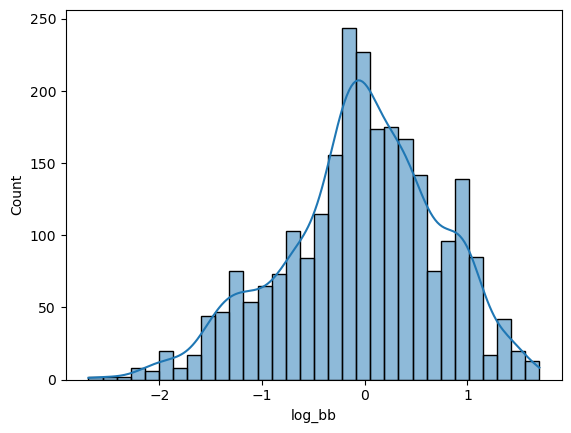

In [112]:
merged_df['log_bb'] = merged_df['log_bb'].astype(float)
sns.histplot(data=merged_df, x="log_bb", kde=True)

How diverse is the data?

[16:19:01] Explicit valence for atom # 5 N, 5, is greater than permitted


Parsed 9245 valid molecules out of 9246 records (100.0%).


[16:19:02] DEPRECATION WARNING: please use MorganGenerator
[16:19:02] DEPRECATION WARNING: please use MorganGenerator
[16:19:02] DEPRECATION WARNING: please use MorganGenerator
[16:19:02] DEPRECATION WARNING: please use MorganGenerator
[16:19:02] DEPRECATION WARNING: please use MorganGenerator
[16:19:02] DEPRECATION WARNING: please use MorganGenerator
[16:19:02] DEPRECATION WARNING: please use MorganGenerator
[16:19:02] DEPRECATION WARNING: please use MorganGenerator
[16:19:02] DEPRECATION WARNING: please use MorganGenerator
[16:19:02] DEPRECATION WARNING: please use MorganGenerator
[16:19:02] DEPRECATION WARNING: please use MorganGenerator
[16:19:02] DEPRECATION WARNING: please use MorganGenerator
[16:19:02] DEPRECATION WARNING: please use MorganGenerator
[16:19:02] DEPRECATION WARNING: please use MorganGenerator
[16:19:02] DEPRECATION WARNING: please use MorganGenerator
[16:19:02] DEPRECATION WARNING: please use MorganGenerator
[16:19:02] DEPRECATION WARNING: please use MorganGenerat

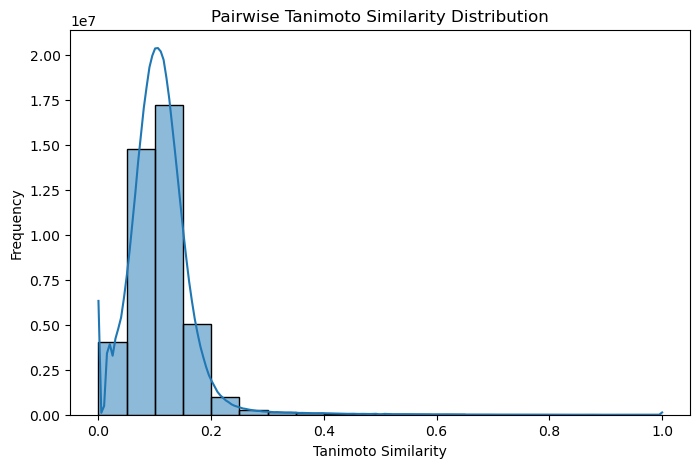

Number of molecule pairs: 42730390
Mean similarity: 0.110
Median similarity: 0.106
Max similarity: 1.000
Min similarity: 0.000


In [ ]:
# Get rid of None SMILES
valid_smiles = [sm for sm in merged_df.smiles.dropna() if isinstance(sm, str) and sm.strip()]
mols = []
for sm in valid_smiles:
    mol = Chem.MolFromSmiles(sm)
    if mol is not None:
        mols.append(mol)

print(f"Parsed {len(mols)} valid molecules out of {len(merged_df)} records ({len(mols)/len(merged_df)*100:.1f}%).")

if len(mols) < 2:
    raise ValueError("Not enough valid molecules to compute similarity.")

fps = [AllChem.GetMorganFingerprintAsBitVect(m, radius=2, nBits=1024) for m in mols]

# Pairwise similarities
similarities = []
num_mols = len(fps)
for i in range(num_mols):
    for j in range(i+1, num_mols):
        sim = DataStructs.TanimotoSimilarity(fps[i], fps[j])
        similarities.append(sim)

plt.figure(figsize=(8,5))
sns.histplot(similarities, bins=20, kde=True)
plt.title("Pairwise Tanimoto Similarity Distribution")
plt.xlabel("Tanimoto Similarity")
plt.ylabel("Frequency")
plt.savefig('_images/pairwise_tanimoto_similarity.png')
plt.show()

print(f"Number of molecule pairs: {len(similarities)}")
print(f"Mean similarity: {np.mean(similarities):.3f}")
print(f"Median similarity: {np.median(similarities):.3f}")
print(f"Max similarity: {np.max(similarities):.3f}")
print(f"Min similarity: {np.min(similarities):.3f}")

Almost no molecular similarity - good. 

How about chemical space visualisation with tSNE?

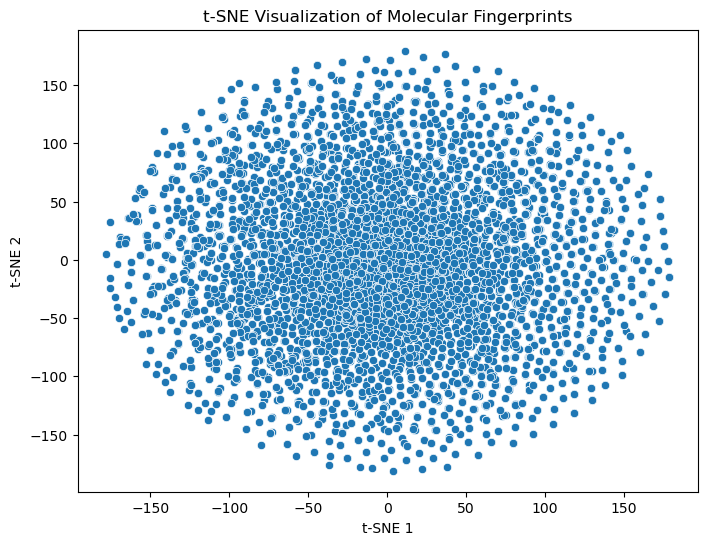

In [114]:
from sklearn.manifold import TSNE
import pandas as pd

# Use the same fingerprints from above, convert to numpy arrays
def fp_to_array(fp):
    arr = np.zeros((1,), dtype=np.uint8)
    DataStructs.ConvertToNumpyArray(fp, arr)
    return arr

fp_arrays = np.array([fp_to_array(fp) for fp in fps])

# Run t-SNE to reduce fingerprint dimensionality to 2D
tsne = TSNE(n_components=2, random_state=42, perplexity=5)
fp_tsne = tsne.fit_transform(fp_arrays)

# Plot t-SNE embedding
plt.figure(figsize=(8,6))
sns.scatterplot(x=fp_tsne[:,0], y=fp_tsne[:,1])
plt.title("t-SNE Visualization of Molecular Fingerprints")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.savefig('_images/cluster_molecule_tsne.png')
plt.show()



[16:26:03] Explicit valence for atom # 8 C greater than permitted
[16:26:04] Explicit valence for atom # 8 C greater than permitted


Number of molecules: 9245
Number of unique scaffolds: 3723
Scaffold diversity ratio: 0.403

Top 10 most frequent scaffolds:
c1ccccc1: 493
O=C1C=CC2C(=C1)CC[C@@H]1C2CCC2CCC[C@H]21: 123
O=C1C=CC2C(=C1)CCC1C3CCCC3CCC21: 95
O=C1CC(=O)NC(=O)N1: 70
O=C1CN=C(c2ccccc2)c2ccccc2N1: 63
c1ccc(Cc2ccccc2)cc1: 61
O=C1C=CC2C(=C1)CC[C@H]1[C@@H]3CCCC3CC[C@H]21: 61
c1ccc2c(c1)Nc1ccccc1S2: 55
O=C1C=C2CC[C@H]3[C@@H]4CCCC4CC[C@@H]3C2CC1: 52
O=C1C=CC2C(=C1)CC[C@H]1C2CCC2CCC[C@H]21: 40


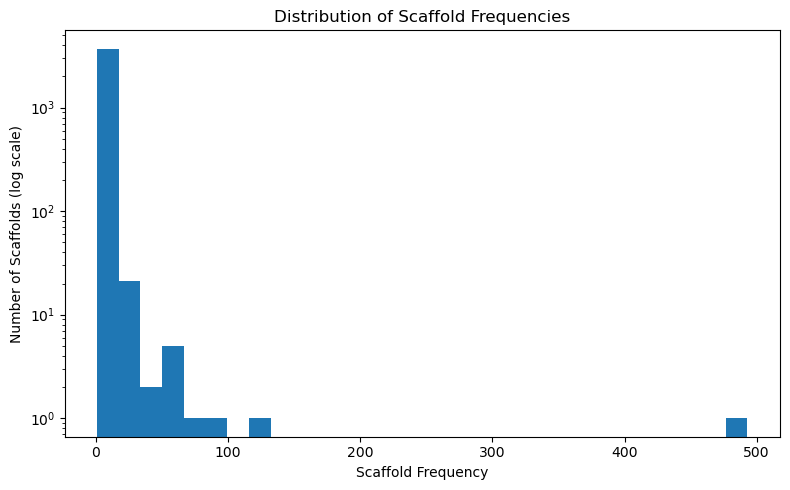

In [ ]:
scaffold_smiles = []

for i, mol in enumerate(mols):
    if mol is None:
        continue
    try:
        scaffold = MurckoScaffold.GetScaffoldForMol(mol)
        if scaffold is None:
            continue
        smi = Chem.MolToSmiles(scaffold)
        if smi:  # avoid empty strings
            scaffold_smiles.append(smi)
    except Exception as e:
        # print(f"Skipping molecule {i} due to error: {e}")
        continue

scaffold_counts = Counter(scaffold_smiles)

num_molecules = len([m for m in mols if m is not None])
num_unique_scaffolds = len(scaffold_counts)
scaffold_diversity_ratio = num_unique_scaffolds / num_molecules

print(f"Number of molecules: {num_molecules}")
print(f"Number of unique scaffolds: {num_unique_scaffolds}")
print(f"Scaffold diversity ratio: {scaffold_diversity_ratio:.3f}")

# Print top 10 most common scaffolds
print("\nTop 10 most frequent scaffolds:")
for scaffold, count in scaffold_counts.most_common(10):
    print(f"{scaffold}: {count}")

# Plot frequency distribution
counts = list(scaffold_counts.values())
plt.figure(figsize=(8,5))
plt.hist(counts, bins=30, log=True)
plt.xlabel("Scaffold Frequency")
plt.ylabel("Number of Scaffolds (log scale)")
plt.title("Distribution of Scaffold Frequencies")
plt.tight_layout()
plt.savefig("_images/scaffold_freq.png")
plt.show()


[16:39:27] DEPRECATION WARNING: please use MorganGenerator
[16:39:27] DEPRECATION WARNING: please use MorganGenerator
[16:39:27] DEPRECATION WARNING: please use MorganGenerator
[16:39:27] DEPRECATION WARNING: please use MorganGenerator
[16:39:27] DEPRECATION WARNING: please use MorganGenerator
[16:39:27] DEPRECATION WARNING: please use MorganGenerator
[16:39:27] DEPRECATION WARNING: please use MorganGenerator
[16:39:27] DEPRECATION WARNING: please use MorganGenerator
[16:39:27] DEPRECATION WARNING: please use MorganGenerator
[16:39:27] DEPRECATION WARNING: please use MorganGenerator
[16:39:27] DEPRECATION WARNING: please use MorganGenerator
[16:39:27] DEPRECATION WARNING: please use MorganGenerator
[16:39:27] DEPRECATION WARNING: please use MorganGenerator
[16:39:27] DEPRECATION WARNING: please use MorganGenerator
[16:39:27] DEPRECATION WARNING: please use MorganGenerator
[16:39:27] DEPRECATION WARNING: please use MorganGenerator
[16:39:27] DEPRECATION WARNING: please use MorganGenerat

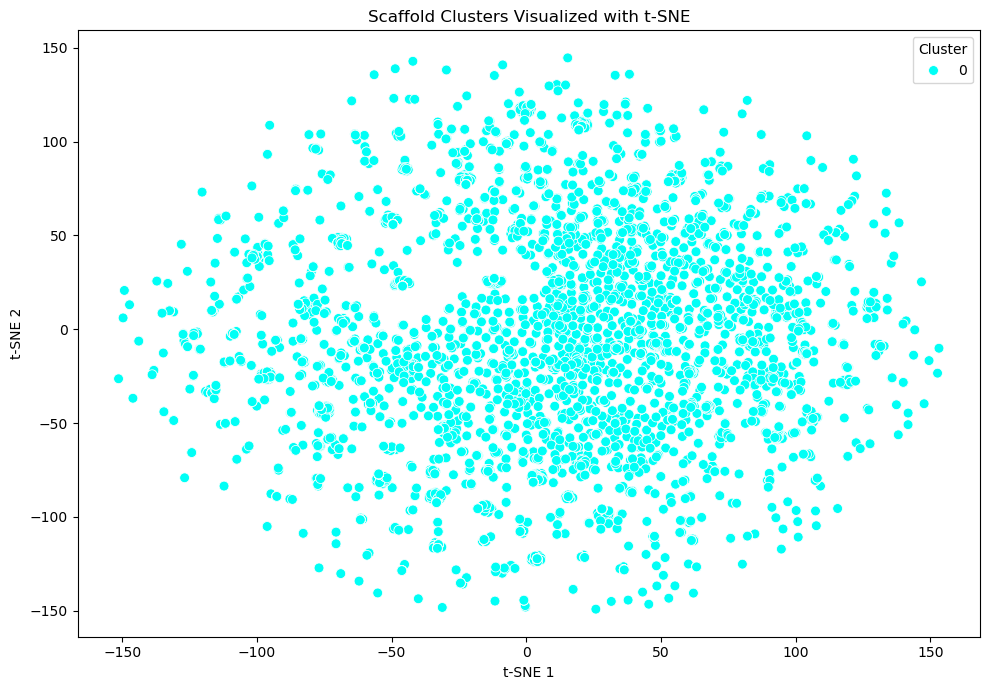

In [ ]:
from rdkit import Chem, DataStructs
from rdkit.Chem import AllChem
from sklearn.cluster import AgglomerativeClustering

scaffold_fps = []
for smi in scaffold_smiles:
    mol = Chem.MolFromSmiles(smi)
    if mol is None:
        continue
    fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius=2, nBits=1024)
    scaffold_fps.append(fp)

def fp_to_array(fp):
    arr = np.zeros((1,), dtype=np.uint8)
    DataStructs.ConvertToNumpyArray(fp, arr)
    return arr

scaffold_fp_arrays = np.array([fp_to_array(fp) for fp in scaffold_fps])

cluster_model = AgglomerativeClustering(
    n_clusters=None,
    distance_threshold=20.0,  # Adjust based on your data scale
    metric='euclidean',
    linkage='average'
)
cluster_labels = cluster_model.fit_predict(scaffold_fp_arrays)

tsne = TSNE(n_components=2, random_state=42, perplexity=10)
scaffold_tsne = tsne.fit_transform(scaffold_fp_arrays)

plt.figure(figsize=(10,7))
palette = sns.color_palette("hsv", len(np.unique(cluster_labels)))
sns.scatterplot(
    x=scaffold_tsne[:,0], y=scaffold_tsne[:,1],
    hue=cluster_labels, palette=palette, legend='full', s=50
)
plt.title("Scaffold Clusters Visualized with t-SNE")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.legend(title='Cluster')
plt.tight_layout()
plt.savefig('_images/cluster_scaffold_tsne.png')
plt.show()


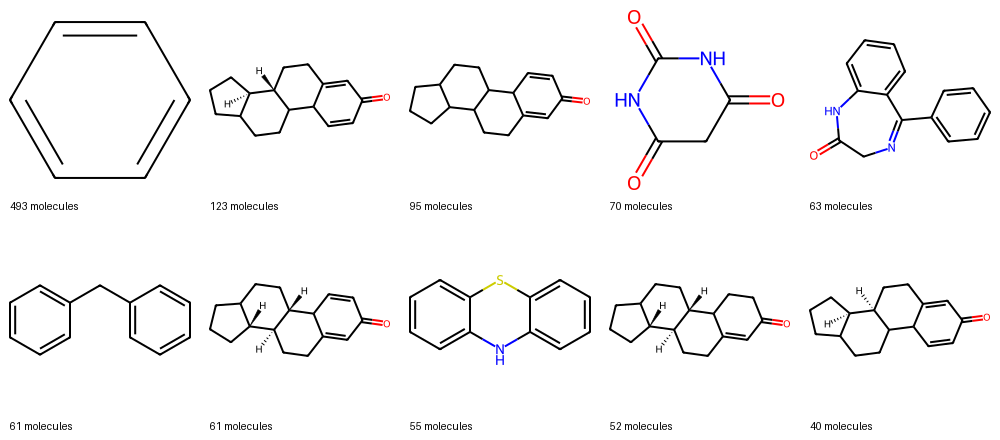

In [ ]:
top_n = 10

top_scaffolds = scaffold_counts.most_common(top_n)
scaffold_mols = [Chem.MolFromSmiles(smi) for smi, _ in top_scaffolds]
scaffold_labels = [f"{count} molecules" for _, count in top_scaffolds]

mol_size = (200, 200)
images = [Draw.MolToImage(mol, size=mol_size) for mol in scaffold_mols]

def add_label(img, label, size=(200, 220)):
    new_img = Image.new("RGB", size, "white")
    new_img.paste(img, (0, 0))
    draw = ImageDraw.Draw(new_img)
    draw.text((10, 200), label, fill="black") 
    return new_img

labeled_images = [add_label(img, label) for img, label in zip(images, scaffold_labels)]

cols = 5
rows = (len(labeled_images) + cols - 1) // cols
grid_width = mol_size[0] * cols
grid_height = 220 * rows 

grid_img = Image.new("RGB", (grid_width, grid_height), "white")

for idx, img in enumerate(labeled_images):
    x = (idx % cols) * mol_size[0]
    y = (idx // cols) * 220
    grid_img.paste(img, (x, y))

grid_img.save("_images/top_10_scaffolds.png")
display(grid_img)

Some groups but they're small. The most frequent are aromatics with some clusters of sterol-looking things. So we have a diverse dataset!

In [124]:
# Dump to file.

merged_df.to_csv(DATA / f"{readout}_merged.csv")